# Simple Linear Regression — Salary vs. Years of Experience

Predicting salary from a single feature, years of experience, using ordinary least squares linear
regression. This is the most basic supervised learning exercise — one feature, one target, a straight
line — and a good place to see the mechanics that multiple regression later builds on.

**Dataset:** 30 employees, 2 columns (`YearsExperience`, `Salary`). No missing values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("Salary_Data.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (30, 2)


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [3]:
print("--- Missing values ---")
print(df.isnull().sum())
print("\n--- Summary statistics ---")
df.describe()

--- Missing values ---
YearsExperience    0
Salary             0
dtype: int64

--- Summary statistics ---


,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


## 2. What simple linear regression is doing

With one feature, linear regression fits a straight line through the data:

$$\text{Salary} = b_0 + b_1 \times \text{YearsExperience}$$

- $b_1$ (the **slope**) is how much salary is predicted to increase for each additional year of
  experience.
- $b_0$ (the **intercept**) is the predicted salary at zero years of experience — a mathematical anchor
  point for the line, not necessarily a realistic real-world value.

The model finds the exact $b_0$ and $b_1$ that minimize the total squared vertical distance between the
line and every real data point (**ordinary least squares**). Those actual fitted numbers are shown in
Section 5, after training.

## 3. Exploratory visualization

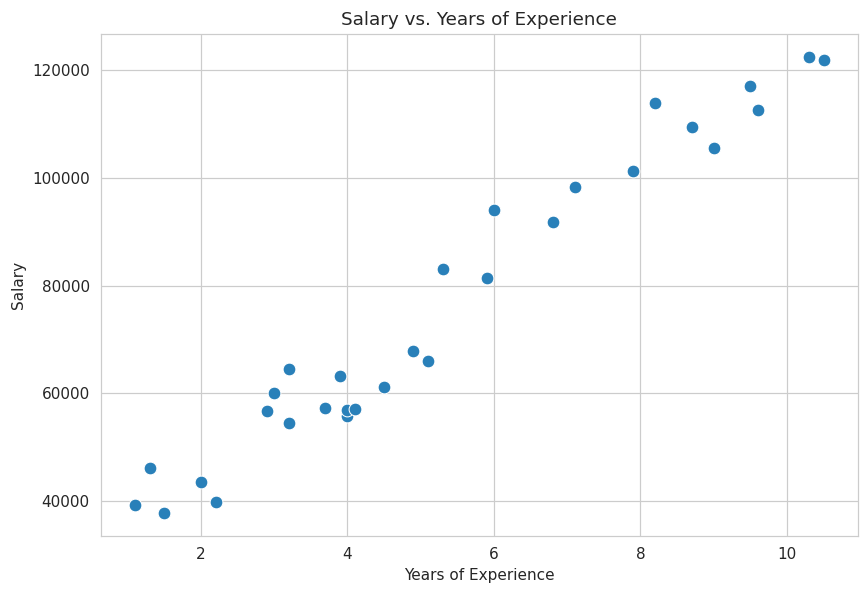

In [4]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=df, x="YearsExperience", y="Salary", s=70, color="#2980b9")
plt.title("Salary vs. Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.tight_layout()
plt.show()

In [5]:
correlation = df["YearsExperience"].corr(df["Salary"])
print(f"Correlation between YearsExperience and Salary: {correlation:.3f}")

Correlation between YearsExperience and Salary: 0.978


The relationship is visibly close to a straight line already, with a very strong correlation
(~0.98) — exactly the kind of data simple linear regression is suited for. Real-world data is rarely this
clean; this dataset is a standard teaching example specifically because the relationship is so clear.

## 4. Train/test split

In [6]:
X = df[["YearsExperience"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 24, Test size: 6


With only 30 rows total, the test set here is just 6 data points — small enough that a single split
carries real noise. That's called out directly in Section 8 with cross-validation, rather than treating
this one split as the full picture.

## 5. Train the model and interpret the coefficients

In [7]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Slope (b1):     {model.coef_[0]:,.2f}")
print(f"Intercept (b0): {model.intercept_:,.2f}")
print(f"\nEquation: Salary = {model.intercept_:,.2f} + {model.coef_[0]:,.2f} \u00d7 YearsExperience")

Slope (b1):     9,423.82
Intercept (b0): 25,321.58

Equation: Salary = 25,321.58 + 9,423.82 × YearsExperience


**Reading the coefficients directly:** each additional year of experience is associated with about
**$9,424** more in predicted salary. The intercept (~$25,322) is the line's mathematical starting point at
0 years of experience — useful for defining the line, but not necessarily a meaningful real-world starting
salary, since it's an extrapolation slightly beyond the actual data range (which starts at 1.1 years).

## 6. Visualizing the fitted line

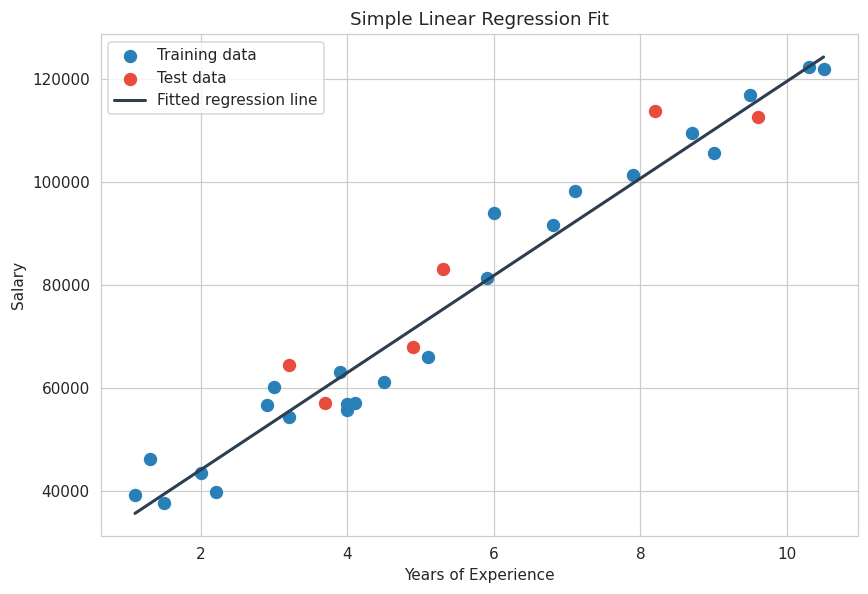

In [8]:
plt.figure(figsize=(8, 5.5))
plt.scatter(X_train, y_train, color="#2980b9", s=60, label="Training data")
plt.scatter(X_test, y_test, color="#e74c3c", s=60, label="Test data")

x_range = np.linspace(df["YearsExperience"].min(), df["YearsExperience"].max(), 100).reshape(-1, 1)
y_range = model.predict(pd.DataFrame(x_range, columns=["YearsExperience"]))
plt.plot(x_range, y_range, color="#2c3e50", linewidth=2, label="Fitted regression line")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Simple Linear Regression Fit")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Evaluation

In [9]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R\u00b2 Score: {r2:.4f}")
print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")

R² Score: 0.9024
RMSE: 7,059.04
MAE:  6,286.45


**R² ≈ 0.90** means the model explains about 90% of the variation in salary using years of
experience alone. **MAE ≈ $6,286** means predictions are, on average, about that far off from the real
salary on this small test set.

## 8. Cross-validation — since the test set is only 6 points

In [10]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2 = cross_val_score(LinearRegression(), X, y, cv=cv, scoring="r2")

print(f"5-fold CV R\u00b2: {cv_r2.mean():.4f} (+/- {cv_r2.std():.4f})")
print(f"Per-fold: {np.round(cv_r2, 3)}")

5-fold CV R²: 0.9224 (+/- 0.0496)
Per-fold: [0.902 0.968 0.916 0.982 0.843]


With a dataset this small, a single train/test split can be noisy — a slightly different random
split could move R² a fair amount just by chance. Cross-validation gives a steadier estimate by testing
across 5 different splits and averaging.

## 9. Residual check

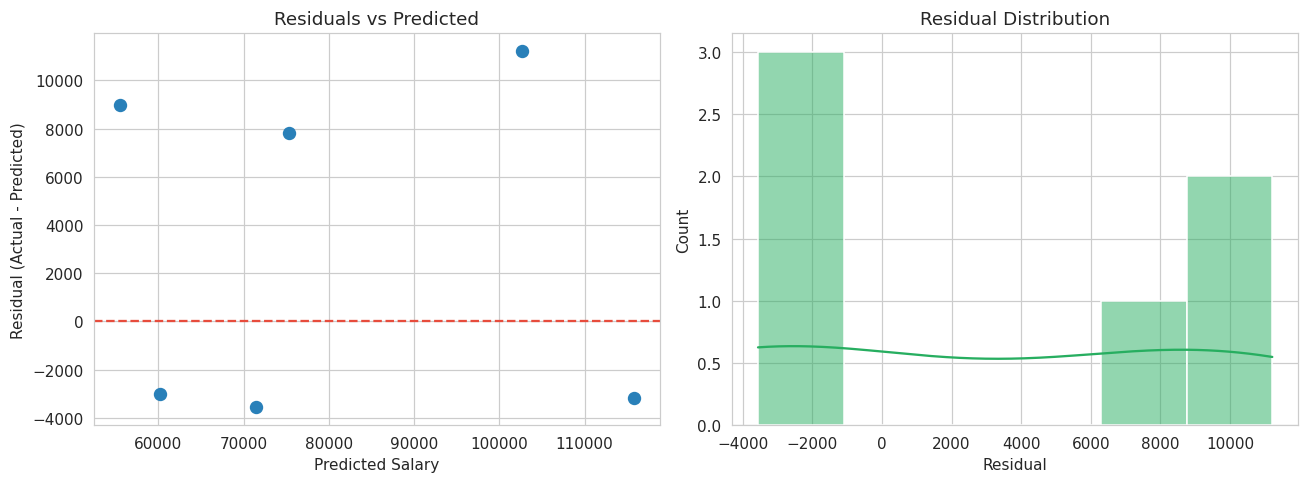

In [11]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(y_pred, residuals, color="#2980b9", s=60)
axes[0].axhline(0, color="#e74c3c", linestyle="--")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

sns.histplot(residuals, bins=6, kde=True, color="#27ae60", ax=axes[1])
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

With only 6 test points, this plot won't look as clean as a residual plot on a large dataset — that's
expected, not a bug. The main thing to check is that residuals don't show an obvious curve or pattern,
which would suggest the true relationship isn't actually linear.

## 10. Predicting for a new value

In [12]:
def predict_salary(model, years_experience):
    """Predict salary for a given number of years of experience."""
    row = pd.DataFrame([[years_experience]], columns=["YearsExperience"])
    prediction = model.predict(row)[0]
    return f"Predicted salary for {years_experience} years of experience: ${prediction:,.2f}"

for years in [2, 5, 8, 12]:
    print(predict_salary(model, years))

Predicted salary for 2 years of experience: $44,169.21
Predicted salary for 5 years of experience: $72,440.66
Predicted salary for 8 years of experience: $100,712.11
Predicted salary for 12 years of experience: $138,407.37


Note the last prediction (12 years) is an **extrapolation** — beyond the training data's actual
range (max 10.5 years). Linear regression will still produce a number, but it's less trustworthy outside
the range the model was actually trained on; the line is only confirmed to fit well within roughly 1-10.5
years.

## 11. Summary

- Fitted a single-feature linear regression: **Salary ≈ 25,322 + 9,424 × YearsExperience**.
- **R² ≈ 0.90** on the test set, confirmed with 5-fold cross-validation given how small the dataset is
  (30 rows total, so a single train/test split alone isn't fully reliable).
- Residuals were checked for pattern (none obvious) rather than just trusting R² at face value.
- Flagged that predictions beyond the training data's actual range (>10.5 years experience) are
  extrapolations and less trustworthy than predictions within the observed range.
- This is the same core idea (minimize squared error to fit a line) that the multiple regression exercise
  elsewhere in this repo extends to several features at once.